<a href="https://colab.research.google.com/github/jmcardenas8/Notebooks-Pregrado-Astronomia/blob/main/Termodinamica/Termo1_jm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Trabajo Python 1: Formula de Timoshenko en Tiras Bimetalicas**
<br>

### &nbsp; **Termodinamica:**

>  &nbsp; &nbsp; *Juan Manuel Cárdenas*


<br>

___

<br>

<p align="justify"> La fórmula de Timochenko (S. Timoshenko, Analysis of Bi-metal Thermostats. J.O.S.A. & R.S.I., 11(3) (1925) 233-255) para determinar el radio de curvatura R, de una tira bimetálica que se calienta uniformemente desde una temperatura T hasta T + $\Delta$T, está dada por:</p>

$$ R = \frac{ x\left[ 3\left( 1+m \right)^{2}+ \left(1+mn\right) \left( m^{2}+1/mn\right) \right] } {  6\left( \alpha_{2}-\alpha_{1}\right)\Delta t \left( 1+m \right)^{2}   } $$

Con:

> $ x = x_{1} + x_{2}$ <br>
> $ m = x_{1}/ x_{2}$ <br>
> $ n = Y1 / Y2 $



Donde $x_{1}$ y $x_{2}$ son los espesores de los metales 1 y 2, mientras que $Y_{1}$ y $Y_{2}$ son los módulos de elasticidades de Young de los metales 1 y 2.
$\alpha_{1}$ y $\alpha_{2}$ son los coeficientes lineales de los metales 1 y 2.  <br><br><br>

<p align="justify"> Algunas de las combinaciones de materiales mas comunmente empleadas en tiras bimetalicas que producen cambios apreciables de curvatura para pequeñas variaciones de temperatura se muestran a continuacion, y tienen diversas aplicaciones electro-mecanicas como en relojes, termostatos, termometros, alarmas, motores u otros dispositivos.<br></p>

* Hierro y Níquel <br>
* Latón y Acero al Carbono <br>
* Cobre y Constantán <br>
* Invar y Acero al Carbono <br><br>

  
<p align="justify"> El invar es una aleacion de hierro (64%) y níquel (36%), mas especificamente (FeNi36) es ampliamente usado por su pequeño coeficiente de dilatacion. El acero al carbon es una composicion de varios tipos de acero usualmente usado en la construccion. Y Finalmente el Constantán es una aleacion de cobre (55%) y níquel (45%) </p>


####**Modulos de Young (Y) y coeficientes lineales ($\alpha$) de los materiales:** <br>

Aleación INVAR FeNi36
> $\alpha$ =  $0.4-2.0*10^{-6} K^{-1}$ <br>
> Y = 135-145 GPa

Aluminio:
> $\alpha$ = $24.0*10^{-6} K^{-1}$ <br>
> Y = 70 GPa

Latón:
> $\alpha$= $18.0*10^{-6} K^{-1}$ <br>
> Y = 90 GPa

Cobre:
> $\alpha$ = $17.0*10^{-6} K^{-1}$ <br>
> Y = 110 GPa

Hierro:
> $\alpha$ = $12* 10^{-6} K^{-1}$ <br>
> Y = 190,211 GPa

Acero al carbono:
> $\alpha$ = $10.8* 10^{-6} K^{-1}$ <br>
> Y = 195-205 GPa

Niquel:
> $\alpha$ = $13* 10^{-6} K^{-1}$ <br>
> Y = 204 GPa

Constantán
> $\alpha$ = $14.9* 10^{-6} K^{-1}$ <br>
> Y =  162 GPa







In [ ]:
import numpy as np
import matplotlib.pyplot as plt

Arreglos de los espesores, modulos de young, coef lineales y variacion de temperatura:

In [ ]:
mater = ['Hierro', 'Níquel', 'Latón' ,'Acero Carbono', 'Cobre', 'Constantán','Invar']

# espesores de los metales [mm]
x1 = np.arange(0.1, 10, 0.3)
x2 = np.arange(0.1, 10, 0.3)

# modulo young [GPa]
Y = np.array([190.211, 204, 90 ,205, 110, 162, 145])

# coeficientes lineales [k^-1]
a = np.array([12, 13, 18, 10.8, 17, 14.9, 2.0])*10**(-6)

# variacion temperatura [k]
ΔT = 1
ΔT_list = np.arange(1,20,1) # para diveresas variaciones de T

funcion del radio de curvatura de timosheko

In [ ]:
def timoshenko(x1,x2,Y1,Y2,a2,a1,ΔT):
  x = x1 + x2 # suma de espesores
  m = x1/x2  # razon espesores
  n = Y1/Y2  # razon modulos young

  P = x*( 3*(1+m)**2+(1+m*n)*(m**2+ 1/(m*n)) ) # numerador
  Q = 6*(a2-a1)*ΔT*((1+m)**2) # denominador
  R = P / Q # radio de curvatura
  return R

### **Variacion del Radio de Curvatura dependiendo del cambio del Espesor**
<br>

Para espesores iguales en ambas laminas

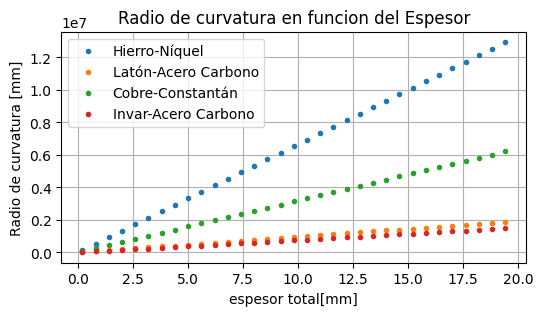

In [ ]:
# indices de cada material
i1 = mater.index('Hierro'); i2 = mater.index('Níquel')
i3 = mater.index('Acero Carbono'); i4 = mater.index('Latón')
i5 = mater.index('Constantán'); i6 = mater.index('Cobre')
i7 = mater.index('Invar')

# evaluando el radio para cada material
R_fe_ni = timoshenko(x1,x2,Y[i1],Y[i2],a[i2],a[i1],ΔT)
R_la_ac = timoshenko(x1,x2,Y[i3],Y[i4],a[i4],a[i3],ΔT)
R_cu_con = timoshenko(x1,x2,Y[i5],Y[i6],a[i6],a[i5],ΔT)
R_in_ac = timoshenko(x1,x2,Y[i7],Y[i3],a[i3],a[i7],ΔT)

# grafica
plt.figure(figsize=(6,3))
plt.plot(x1+x2,R_fe_ni, '.', label='Hierro-Níquel')
plt.plot(x1+x2,R_la_ac, '.', label='Latón-Acero Carbono')
plt.plot(x1+x2,R_cu_con , '.', label='Cobre-Constantán')
plt.plot(x1+x2,R_in_ac , '.', label='Invar-Acero Carbono')
plt.title('Radio de curvatura en funcion del Espesor')
plt.ylabel('Radio de curvatura [mm]')
plt.xlabel('espesor total[mm]')
plt.legend()
plt.grid()

Para un espesor fijo y el otro variable

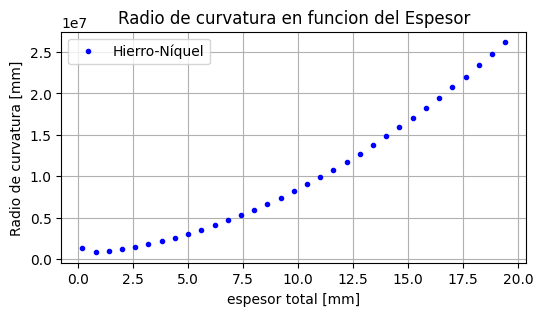

In [ ]:
# tomamos arbitrariamente un valor fijo y el otro variable para los espesores
R_fe_ni_mod = timoshenko(x1,x2[2],Y[i1],Y[i2],a[i2],a[i1],ΔT)

plt.figure(figsize=(6,3))
plt.plot(x1+x2, R_fe_ni_mod , 'b.', label='Hierro-Níquel')
plt.title('Radio de curvatura en funcion del Espesor')
plt.ylabel('Radio de curvatura [mm]')
plt.xlabel('espesor total [mm]')
plt.legend()
plt.grid()

### **Variacion del Radio de Curvatura dependiendo del cambio de temperatura**

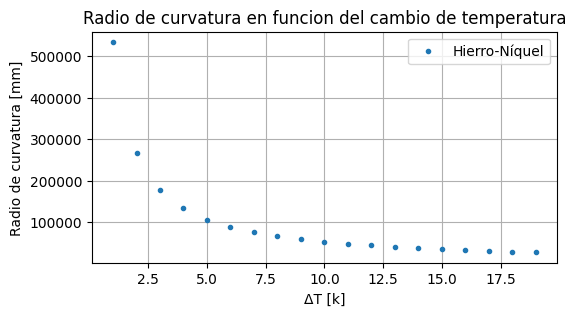

In [ ]:
# tomamos los dos espesores fijos y el cambio en la temperatura variable
R_fe_ni_ = timoshenko(x1[1],x2[1],Y[i1],Y[i2],a[i2],a[i1],ΔT_list)

plt.figure(figsize=(6,3))
plt.plot(ΔT_list, R_fe_ni_ , '.', label='Hierro-Níquel')
plt.title('Radio de curvatura en funcion del cambio de temperatura')
plt.ylabel('Radio de curvatura [mm]')
plt.xlabel('ΔT [k]')
plt.legend()
plt.grid()

## **Conclusiones**

**¿Qué efecto tienen los espesores en este comportamiento?** <br><br>



Para el caso donde ambos espesores de las tiras es igual se puede concluir que el cambio del radio de curvatura de timoshencko con respecto a tal espesor es linal, es directamente proporcional, como se puede observar de la primera grafica, Lo que concuerda con lo dicho por el autor en "ANALYSIS OF BI-METAL THERMOSTATS" (pag 235) "**la curvatura** ($\frac{1}{R}$ **inverso del radio de curvatura**) es proporcional a la diferencia de elongacion de los dos metales e **inversamente** proporcional a el **espesor** de la tira". Hay que notar que la tira bimetalica que presenta mayor variacion del radio respecto al espesor, y por tanto menor curvatura, es la combinacion hierro-niquel. Mientras la que presenta menores cambios de radio de curvatura y por tanto mayor curvatura es la combinacion invar-acero al carbono. <br><br>

<p align="justify"> Por otra parte, en el segundo caso en la segunda figura, si se toma un espesor para las tiras fijo y el otro variable, el comportamiento deja de ser lineal y toma una tendencia posiblemente polinomica o potencial. Tendencia semejante que tambien es observada cuando se fijan dos espesores y se hacen variaciones de los cambios de temperatura como se muestra en la tercer figura. </p>






<br><br><br>

## **Bibliografia:**

[1] Timoshenko, ANALYSIS OF BI-METAL THERMOSTATS, recuperado de: https://www.academia.edu/42454949/ANALYSIS_OF_BI_METAL_THERMOSTATS

[2] ulpgc.es, modulos de young y cizalladura, recuperado de: https://www2.ulpgc.es/hege/almacen/download/5/5479/Tabla_Modulos_de_Young_y_cizalladura.pdf

[3] Módulos de elasticidad, , recuperado de: http://www.sc.ehu.es/sbweb/fisica/solido/din_rotacion/alargamiento/alargamiento.htm


[4] Coeficientes lineales, recuperado de: https://www.tochtli.fisica.uson.mx/fluidos%20y%20calor/tablas/Coeficientes%20de%20dilatacion.htm


[5] Coeficientes-de-dilatacion,recuperado de: https://www.fisicanet.com.ar/fisica/termostatica/tb01-coeficientes-de-dilatacion.php


[6] material Constantán, recuperado de: https://es.wikipedia.org/wiki/Constant%C3%A1n


[7] material invar, recuperado de:  https://material-properties.org/es/que-es-invar-propiedades-y-usos-definicion/

[8] tabla-de-coeficientes lineales, recuperado de: https://esingenieria.pro/dilatacion-y-contraccion-tabla-de-coeficientes/


